In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical

2026-06-15 07:29:56.542874: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781508596.786853      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781508596.857027      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781508597.417794      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781508597.417834      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781508597.417837      58 computation_placer.cc:177] computation placer alr

In [2]:
BASE_DIR = '/kaggle/input/datasets/jangedoo/utkface-new/UTKFace'

image_paths, age_labels, gender_labels, race_labels = [], [], [], []

for filename in os.listdir(BASE_DIR):
    try:
        parts = filename.split('_')
        age, gender, race = int(parts[0]), int(parts[1]), int(parts[2])
        image_paths.append(filename)
        age_labels.append(age)
        gender_labels.append(gender)
        race_labels.append(race)
    except:
        continue

print(f"Total images: {len(image_paths)}")

Total images: 23705


In [4]:
IMG_SIZE = 128

def load_image(filename):
    img = cv2.imread(os.path.join(BASE_DIR, filename), cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    return img / 255.0

X = np.array([load_image(f) for f in image_paths], dtype='float32')
X = X.reshape(-1, IMG_SIZE, IMG_SIZE, 1)

age_labels = np.array(age_labels)
gender_labels = np.array(gender_labels)
race_labels = np.array(race_labels)


print(X.shape, X.dtype, age_labels.shape, gender_labels.shape, race_labels.shape)

(23705, 128, 128, 1) float32 (23705,) (23705,) (23705,)


In [5]:
race_map = {0:'White', 1:'Black/African', 2:'Asian', 3:'Indian', 4:'Others'}
race_labels_oh = to_categorical(race_labels, num_classes=5)

In [6]:
X_train, X_test, age_train, age_test, gender_train, gender_test, race_train, race_test = train_test_split(
    X, age_labels, gender_labels, race_labels_oh, test_size=0.2, random_state=42
)
print(X_train.shape, X_test.shape)

(18964, 128, 128, 1) (4741, 128, 128, 1)


In [7]:
race_labels_oh = to_categorical(race_labels, num_classes=5)

In [8]:
X_train, X_test, age_train, age_test, gender_train, gender_test, race_train, race_test = train_test_split(
    X, age_labels, gender_labels, race_labels_oh, test_size=0.2, random_state=42
)

In [9]:
from sklearn.utils import resample

# get race class index from one-hot training labels
race_train_idx = np.argmax(race_train, axis=1)

unique, counts = np.unique(race_train_idx, return_counts=True)
max_count = counts.max()   # size of the largest class (White)
print("Before oversampling:", dict(zip([race_map[u] for u in unique], counts)))

# for each class, resample (with replacement) up to max_count
oversampled_indices = []
for cls in unique:
    cls_indices = np.where(race_train_idx == cls)[0]
    resampled = resample(cls_indices, replace=True, n_samples=max_count, random_state=42)
    oversampled_indices.extend(resampled)

oversampled_indices = np.array(oversampled_indices)
np.random.shuffle(oversampled_indices)

# apply the SAME indices to every training array so rows stay aligned
X_train      = X_train[oversampled_indices]
age_train    = age_train[oversampled_indices]
gender_train = gender_train[oversampled_indices]
race_train   = race_train[oversampled_indices]

# verify balance
new_idx = np.argmax(race_train, axis=1)
u2, c2 = np.unique(new_idx, return_counts=True)
print("After oversampling: ", dict(zip([race_map[u] for u in u2], c2)))
print("New X_train shape:", X_train.shape)

Before oversampling: {'White': np.int64(8105), 'Black/African': np.int64(3620), 'Asian': np.int64(2730), 'Indian': np.int64(3163), 'Others': np.int64(1346)}
After oversampling:  {'White': np.int64(8105), 'Black/African': np.int64(8105), 'Asian': np.int64(8105), 'Indian': np.int64(8105), 'Others': np.int64(8105)}
New X_train shape: (40525, 128, 128, 1)


In [25]:
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom, RandomBrightness

inputs = Input(shape=(128,128,1))

# data augmentation — varies the (oversampled) images each epoch
x = RandomFlip("horizontal")(inputs)
x = RandomRotation(0.1)(x)
x = RandomZoom(0.1)(x)


x = Conv2D(32, (3,3), activation='relu')(x)
x = MaxPooling2D((2,2))(x)
x = Conv2D(64, (3,3), activation='relu')(x)
x = MaxPooling2D((2,2))(x)
x = Conv2D(128, (3,3), activation='relu')(x)
x = MaxPooling2D((2,2))(x)
x = Conv2D(256, (3,3), activation='relu')(x)
x = MaxPooling2D((2,2))(x)
x = Flatten()(x)

d1 = Dropout(0.3)(Dense(256, activation='relu')(x))
d2 = Dropout(0.3)(Dense(256, activation='relu')(x))
d3 = Dropout(0.3)(Dense(256, activation='relu')(x))

gender_out = Dense(1, activation='sigmoid', name='gender_out')(d1)
age_out    = Dense(1, activation='relu',    name='age_out')(d2)
race_out   = Dense(5, activation='softmax', name='race_out')(d3)

model = Model(inputs=inputs, outputs=[gender_out, age_out, race_out])
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip_1       │ (None, 128, 128,  │          0 │ input_layer_2[0]… │
│ (RandomFlip)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_rotation_1   │ (None, 128, 128,  │          0 │ random_flip_1[0]… │
│ (RandomRotation)    │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_zoom_1       │ (None, 128, 128,  │          0 │ random_rotation_… │
│ (RandomZoom)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 126, 126,  │        320 │ random_zoom_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 63, 63,    │          0 │ conv2d_8[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 61, 61,    │     18,496 │ max_pooling2d_8[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 30, 30,    │          0 │ conv2d_9[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 28, 28,    │     73,856 │ max_pooling2d_9[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_10    │ (None, 14, 14,    │          0 │ conv2d_10[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 12, 12,    │    295,168 │ max_pooling2d_10… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_11    │ (None, 6, 6, 256) │          0 │ conv2d_11[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 9216)      │          0 │ max_pooling2d_11… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 256)       │  2,359,552 │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 256)       │  2,359,552 │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 256)       │  2,359,552 │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 256)       │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 256)       │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 256)       │          0 │ dense_8[0][0]   

 Total params: 7,468,295 (28.49 MB)

 Trainable params: 7,468,295 (28.49 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
model.compile(
    optimizer='adam',
    loss=['binary_crossentropy', 'mae', 'categorical_crossentropy'],
    metrics=[['accuracy'], ['mae'], ['accuracy']],
    loss_weights=[1.0, 0.01, 1.0]
)

In [27]:
model.compile(
    optimizer='adam',
    loss={
        'gender_out': 'binary_crossentropy',
        'age_out': 'mae',
        'race_out': 'categorical_crossentropy'
    },
    metrics={
        'gender_out': 'accuracy',
        'age_out': 'mae',
        'race_out': 'accuracy'
    },
    loss_weights={
        'gender_out': 1.0,
        'age_out': 0.01,
        'race_out': 1.0
    }
)

In [28]:
history = model.fit(
    X_train,
    {'gender_out': gender_train, 'age_out': age_train, 'race_out': race_train},
    validation_data=(X_test, {'gender_out': gender_test, 'age_out': age_test, 'race_out': race_test}),
    epochs=20, batch_size=64
)

Epoch 1/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 29s 40ms/step - age_out_loss: 13.2361 - age_out_mae: 13.2430 - gender_out_accuracy: 0.7464 - gender_out_loss: 0.4989 - loss: 1.9646 - race_out_accuracy: 0.4372 - race_out_loss: 1.3332 - val_age_out_loss: 12.2259 - val_age_out_mae: 12.2731 - val_gender_out_accuracy: 0.8298 - val_gender_out_loss: 0.3744 - val_loss: 1.5978 - val_race_out_accuracy: 0.5836 - val_race_out_loss: 1.0975
Epoch 2/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - age_out_loss: 10.1153 - age_out_mae: 10.1164 - gender_out_accuracy: 0.8312 - gender_out_loss: 0.3705 - loss: 1.5241 - race_out_accuracy: 0.5902 - race_out_loss: 1.0519 - val_age_out_loss: 9.7268 - val_age_out_mae: 9.7149 - val_gender_out_accuracy: 0.8452 - val_gender_out_loss: 0.3262 - val_loss: 1.2965 - val_race_out_accuracy: 0.6828 - val_race_out_loss: 0.8736
Epoch 3/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - age_out_loss: 8.9872 - age_out_mae: 8.9897 - gender_out_accuracy: 0.8552 - gender_out_loss: 0.3241 - l

In [29]:
results = model.evaluate(X_test, [gender_test, age_test, race_test], verbose=1)
print("\nTest results:")
for name, val in zip(model.metrics_names, results):
    print(f"{name}: {val:.4f}")

149/149 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - age_out_loss: 6.9318 - age_out_mae: 6.9139 - gender_out_accuracy: 0.8981 - gender_out_loss: 0.2714 - loss: 1.0032 - race_out_accuracy: 0.7642 - race_out_loss: 0.6645

Test results:
loss: 1.0032
compile_metrics: 0.2714
gender_out_loss: 6.9318
age_out_loss: 0.6645
race_out_loss: 6.9139


149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


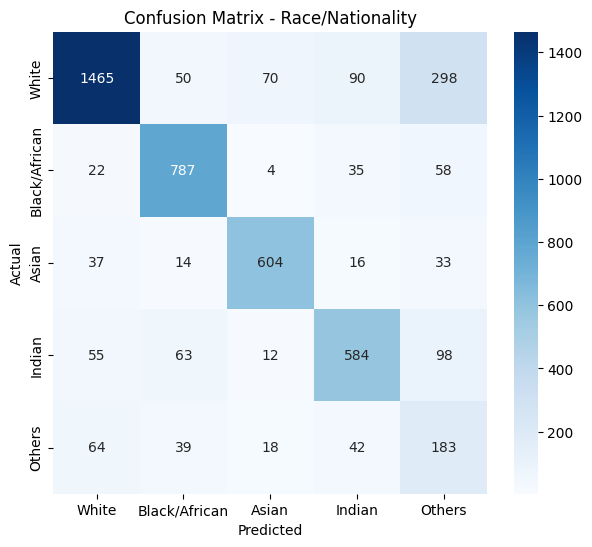

               precision    recall  f1-score   support

        White       0.89      0.74      0.81      1973
Black/African       0.83      0.87      0.85       906
        Asian       0.85      0.86      0.86       704
       Indian       0.76      0.72      0.74       812
       Others       0.27      0.53      0.36       346

     accuracy                           0.76      4741
    macro avg       0.72      0.74      0.72      4741
 weighted avg       0.81      0.76      0.78      4741



In [30]:
preds = model.predict(X_test)
# preds[0]=gender, preds[1]=age, preds[2]=race

race_pred = np.argmax(preds[2], axis=1)
race_true = np.argmax(race_test, axis=1)

cm = confusion_matrix(race_true, race_pred)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=race_map.values(), yticklabels=race_map.values())
plt.title("Confusion Matrix - Race/Nationality")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()

from sklearn.metrics import classification_report
print(classification_report(race_true, race_pred, target_names=list(race_map.values())))

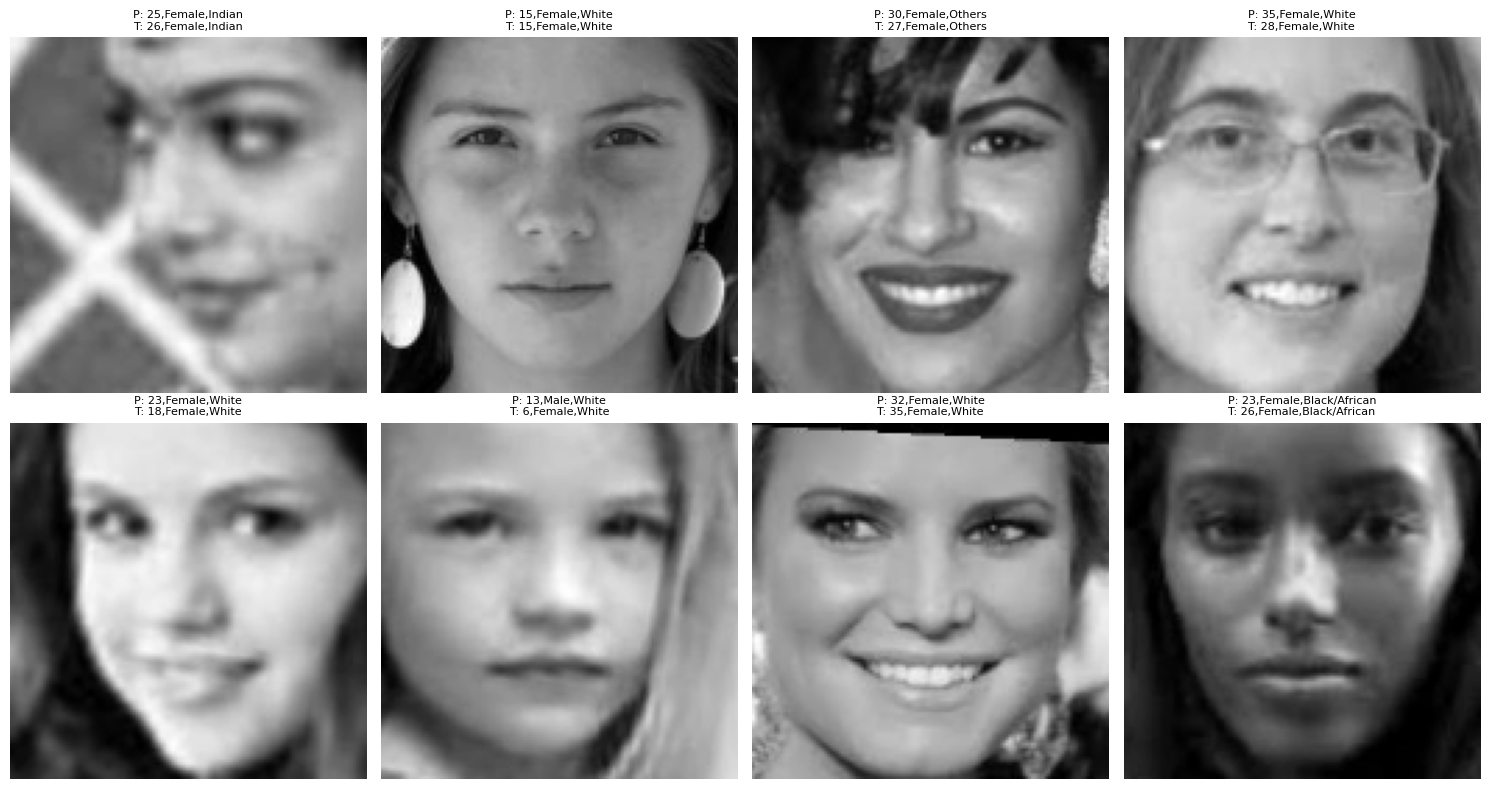

In [31]:
plt.figure(figsize=(15,8))
for i in range(8):
    idx = np.random.randint(0, len(X_test))
    img = X_test[idx].reshape(IMG_SIZE, IMG_SIZE)

    pred_gender = "Male" if preds[0][idx][0] < 0.5 else "Female"
    pred_age    = int(preds[1][idx][0])
    pred_race   = race_map[np.argmax(preds[2][idx])]

    true_gender = "Male" if gender_test[idx] == 0 else "Female"
    true_age    = age_test[idx]
    true_race   = race_map[np.argmax(race_test[idx])]

    plt.subplot(2,4,i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f"P: {pred_age},{pred_gender},{pred_race}\nT: {true_age},{true_gender},{true_race}", fontsize=8)
    plt.axis('off')
plt.tight_layout()
plt.show()

In [32]:
model.save('age_gender_race_model_2.keras')